# Model Comparison, Robustness & Significance Analysis

This notebook is the capstone comparison across all model families trained in notebooks 07–10.
It is designed to be run **after** those notebooks have saved their results CSVs.

## What this notebook does

| § | Section | Purpose |
|---|---------|----------|
| 1 | **Dummy / Chance Baseline** | Anchors all results against a no-skill predictor |
| 2 | **Master Results Table** | All models side-by-side with 95% CIs (best config per family) |
| 3 | **Statistical Significance** | Pairwise Wilcoxon signed-rank tests on fold-level macro F1 |
| 4 | **Noise Sensitivity** | F1 degradation as Gaussian noise is added to test features |
| 5 | **Sensor Dropout / Ablation** | Simulate failed sensors; identify most important modalities |
| 6 | **Cross-Day Performance** | LORO-CV broken down by collection date to expose temporal drift |

**Dataset**: `dataset_A_pruned_5run.csv` — 5 terrain classes, 5-run LORO-CV, all notebooks share identical fold boundaries.

In [4]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon, t as t_dist
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    warnings.warn("XGBoost not available.")

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent


location = "Farm"
RESULTS_DIR = PROJECT_ROOT / "results" / location
DATA_DIR    = PROJECT_ROOT / "data" / "processed" / location
REPORTS_DIR = PROJECT_ROOT / "reports" / "models" / location
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Constants shared across all model notebooks
# ---------------------------------------------------------------------------
RANDOM_STATE = 42
LABEL_COL    = "label"
RUN_COL      = "run_id"
ALPHA        = 0.05

# change the label order for the based on the data.
LABEL_ORDER = [
    "dirt_track",
    "grass",
    "soil",
]

N_CLASSES = len(LABEL_ORDER)

# 5 canonical LORO-CV test runs (run 3 split at temporal midpoint)
RUN_IDS = ["Run1", "Run2", "Run3", "Run4", "Run5"]

# Map each run -> collection date (for cross-day analysis)
RUN_TO_DATE = {
    "Run1":       "2026-04-21",
    "Run2":       "2026-04-21",
    "Run3":       "2026-04-28",
    "Run4":       "2026-04-28",
    "Run5":       "2026-04-28",
}

# Metadata columns — everything else is a feature
ID_COLS = ["window_id", "run_id", "segment_id", "label", "t_start", "t_end", "n_samples"]

sns.set_theme(style="whitegrid", context="notebook")
print(f"Project root : {PROJECT_ROOT}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Reports dir  : {REPORTS_DIR}")

Project root : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
Results dir  : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/Farm
Reports dir  : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm


In [5]:
# ---------------------------------------------------------------------------
# Load per-fold results from all model notebooks
# ---------------------------------------------------------------------------

# 07_baslines
baseline_pf = pd.read_csv(RESULTS_DIR / "baseline_metrics_per_fold.csv")

# 08_base_tuning
tuned_pf  = pd.read_csv(RESULTS_DIR / "tuned_metrics_per_fold.csv")
tuned_sum = pd.read_csv(RESULTS_DIR / "tuned_metrics_summary.csv")

# 09_mlp
mlp_pf  = pd.read_csv(RESULTS_DIR / "mlp_metrics_per_fold.csv")
mlp_sum = pd.read_csv(RESULTS_DIR / "mlp_metrics_summary.csv")

# 10_CNN
cnn_pf  = pd.read_csv(RESULTS_DIR / "cnn" / "cnn_metrics_per_fold.csv")
cnn_sum = pd.read_csv(RESULTS_DIR / "cnn" / "cnn_metrics_summary.csv")

print("Per-fold rows loaded:")
print(f"  Baseline : {len(baseline_pf)}")
print(f"  Tuned    : {len(tuned_pf)}")
print(f"  MLP      : {len(mlp_pf)}")
print(f"  CNN      : {len(cnn_pf)}")

# ---------------------------------------------------------------------------
# Load feature dataset (needed for dummy baseline + robustness tests)
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_DIR / "dataset_A_pruned.csv")
feature_cols = [c for c in df.columns if c not in ID_COLS]

print(f"\nFeature dataset : {df.shape[0]} windows x {len(feature_cols)} features")
print(f"Labels          : {dict(df[LABEL_COL].value_counts())}")
print(f"Runs            : {df[RUN_COL].unique().tolist()}")

# ---------------------------------------------------------------------------
# Helper: 95% CI using t-distribution (n=5 folds, df=4)
# ---------------------------------------------------------------------------
def ci95(values: list) -> tuple:
    """Return (mean, margin) for a 95% CI via t-distribution."""
    arr    = np.array(values, dtype=float)
    n      = len(arr)
    se     = arr.std(ddof=1) / np.sqrt(n)
    t_crit = float(t_dist.ppf(1 - ALPHA / 2, df=n - 1))
    return float(arr.mean()), float(t_crit * se)

# ---------------------------------------------------------------------------
# IMPORTANT: Macro F1 label averaging convention
# ---------------------------------------------------------------------------
# We compute macro F1 over labels=np.unique(y_test) — only classes present
# in each test fold. This matches the convention used in notebooks 07/08
# (where sklearn defaults to this naturally when the model does not predict
# absent classes). The chance level for a 3-class balanced fold is 1/3 ≈ 0.33;
# the stratified dummy achieves ~0.20 due to imbalanced training frequencies.


Per-fold rows loaded:
  Baseline : 160
  Tuned    : 80
  MLP      : 15
  CNN      : 5

Feature dataset : 1583 windows x 141 features
Labels          : {'dirt_track': np.int64(714), 'soil': np.int64(533), 'grass': np.int64(336)}
Runs            : ['Run1', 'Run2', 'Run3', 'Run4', 'Run5']


## §1 — Dummy / Chance Baseline

Every results table needs a no-skill anchor so readers can contextualise whether a given macro F1 is good or mediocre.

- **Stratified dummy**: predicts randomly with class probabilities = training class frequencies. For a perfectly balanced 5-class problem this converges to **macro F1 ≈ 0.20**.
- **Most-frequent dummy**: always predicts the majority class. Macro F1 is near 0 except for that one class.

Both are evaluated under the same 5-fold LORO-CV protocol used by every other model.

In [7]:
dummy_rows = []

for test_run in RUN_IDS:
    train_mask = df[RUN_COL] != test_run
    test_mask  = ~train_mask

    X_train = df.loc[train_mask, feature_cols].to_numpy(dtype=float)
    X_test  = df.loc[test_mask,  feature_cols].to_numpy(dtype=float)
    y_train = df.loc[train_mask, LABEL_COL].to_numpy()
    y_test  = df.loc[test_mask,  LABEL_COL].to_numpy()

    for strategy in ("stratified", "most_frequent"):
        if strategy == "stratified":
            # Average over 20 seeds -- stratified is stochastic
            f1s = [
                f1_score(
                    y_test,
                    DummyClassifier(strategy="stratified", random_state=s)
                        .fit(X_train, y_train).predict(X_test),
                    average="macro",
                    zero_division=0,
                    labels=list(np.unique(y_test)),
                )
                for s in range(20)
            ]
            macro_f1 = float(np.mean(f1s))
            acc      = None
        else:
            d        = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
            y_pred   = d.predict(X_test)
            macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0, labels=list(np.unique(y_test)))
            acc      = float(accuracy_score(y_test, y_pred))

        dummy_rows.append({
            "model":    f"Dummy ({strategy})",
            "test_run": test_run,
            "n_test":   int(test_mask.sum()),
            "macro_f1": macro_f1,
            "accuracy": acc,
        })

dummy_pf = pd.DataFrame(dummy_rows)

dummy_summary = (
    dummy_pf.groupby("model")["macro_f1"]
    .agg(macro_f1_mean="mean", macro_f1_std="std")
    .reset_index()
)
print("=== Dummy Classifier Results ===")
print(dummy_summary.to_string(index=False))
print(f"\nTheoretical chance for {N_CLASSES}-class balanced problem = {1/N_CLASSES:.3f}")

dummy_pf.to_csv(RESULTS_DIR / "dummy_metrics_per_fold.csv", index=False)
print(f"\nSaved -> {RESULTS_DIR / 'dummy_metrics_per_fold.csv'}")

=== Dummy Classifier Results ===
                model  macro_f1_mean  macro_f1_std
Dummy (most_frequent)       0.207917      0.036012
   Dummy (stratified)       0.319952      0.010291

Theoretical chance for 3-class balanced problem = 0.333

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/Farm/dummy_metrics_per_fold.csv


## §2 — Master Results Table

One row per model family using the **best-performing configuration** (feature set + imbalance strategy, selected by macro F1 mean from the respective notebook's summary CSV).

Confidence intervals use the t-distribution with df = 4 (five LORO folds).

> **Reading the table**: dummy rows are the floor — a model is only useful if its worst-fold F1 also substantially exceeds the stratified dummy (~0.20).

In [8]:
# Best config per tuned classical model (highest macro_f1_mean)
best_tuned = (
    tuned_sum
    .sort_values("macro_f1_mean", ascending=False)
    .groupby("model", sort=False)
    .first()
    .reset_index()
)

def tuned_fold_f1(model_name, feature_set, imbalance):
    mask = (
        (tuned_pf["model"]       == model_name) &
        (tuned_pf["feature_set"] == feature_set) &
        (tuned_pf["imbalance"]   == imbalance)
    )
    return tuned_pf.loc[mask, "macro_f1"].tolist()

table_rows = []

# --- Dummy baselines (anchor rows) ---
for strategy in ("stratified", "most_frequent"):
    sub = dummy_pf.loc[dummy_pf["model"] == f"Dummy ({strategy})", "macro_f1"].tolist()
    mean_f, margin = ci95(sub)
    table_rows.append({
        "Model":         f"Dummy ({strategy})",
        "Config":        "—",
        "F1 mean":       mean_f,
        "95% CI margin": margin,
        "F1 std":        float(np.std(sub, ddof=1)),
        "Worst fold F1": float(min(sub)),
        "Folds":         len(sub),
    })

# --- Best tuned classical models ---
for _, row in best_tuned.iterrows():
    folds = tuned_fold_f1(row["model"], row["feature_set"], row["imbalance"])
    mean_f, margin = ci95(folds)
    table_rows.append({
        "Model":         row["model"],
        "Config":        f"{row['feature_set']}, {row['imbalance']}",
        "F1 mean":       mean_f,
        "95% CI margin": margin,
        "F1 std":        float(np.std(folds, ddof=1)),
        "Worst fold F1": float(min(folds)),
        "Folds":         len(folds),
    })

# --- Best MLP config ---
best_mlp_row = mlp_sum.loc[mlp_sum["macro_f1_mean"].idxmax()]
mlp_folds = mlp_pf.loc[
    mlp_pf["feature_set"] == best_mlp_row["feature_set"], "macro_f1"
].tolist()
mean_f, margin = ci95(mlp_folds)
table_rows.append({
    "Model":         "MLP",
    "Config":        str(best_mlp_row["feature_set"]),
    "F1 mean":       mean_f,
    "95% CI margin": margin,
    "F1 std":        float(np.std(mlp_folds, ddof=1)),
    "Worst fold F1": float(min(mlp_folds)),
    "Folds":         len(mlp_folds),
})

# --- CNN ---
cnn_folds = cnn_pf["macro_f1"].tolist()
mean_f, margin = ci95(cnn_folds)
table_rows.append({
    "Model":         "CNN",
    "Config":        "raw signal (5 ch)",
    "F1 mean":       mean_f,
    "95% CI margin": margin,
    "F1 std":        float(np.std(cnn_folds, ddof=1)),
    "Worst fold F1": float(min(cnn_folds)),
    "Folds":         len(cnn_folds),
})

master_df = (
    pd.DataFrame(table_rows)
    .sort_values("F1 mean", ascending=False)
    .reset_index(drop=True)
)

# Pretty-print version
disp = master_df.copy()
disp["Macro F1 (mean +/- CI95)"] = (
    disp["F1 mean"].map("{:.3f}".format)
    + " +/- "
    + disp["95% CI margin"].map("{:.3f}".format)
)
disp["F1 std"]        = disp["F1 std"].map("{:.3f}".format)
disp["Worst fold F1"] = disp["Worst fold F1"].map("{:.3f}".format)
disp = disp[["Model", "Config", "Macro F1 (mean +/- CI95)", "F1 std", "Worst fold F1", "Folds"]]

print("=== Master Model Comparison ===")
print(f"5-class LORO-CV  |  Stratified chance = {1/N_CLASSES:.3f}  |  alpha = {ALPHA}")
print()
print(disp.to_string(index=False))

master_df.to_csv(RESULTS_DIR / "master_model_comparison.csv", index=False)
print(f"\nSaved -> {RESULTS_DIR / 'master_model_comparison.csv'}")

=== Master Model Comparison ===
5-class LORO-CV  |  Stratified chance = 0.333  |  alpha = 0.05

                Model            Config Macro F1 (mean +/- CI95) F1 std Worst fold F1  Folds
                  SVM   all, unweighted          0.866 +/- 0.075  0.061         0.813      5
   LogisticRegression   all, unweighted          0.865 +/- 0.084  0.067         0.786      5
              XGBoost     all, balanced          0.861 +/- 0.060  0.049         0.823      5
                  CNN raw signal (5 ch)          0.849 +/- 0.100  0.081         0.721      5
                  MLP               all          0.840 +/- 0.088  0.071         0.746      5
         RandomForest   all, unweighted          0.840 +/- 0.059  0.047         0.794      5
   Dummy (stratified)                 —          0.320 +/- 0.013  0.010         0.305      5
Dummy (most_frequent)                 —          0.208 +/- 0.045  0.036         0.164      5

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_in

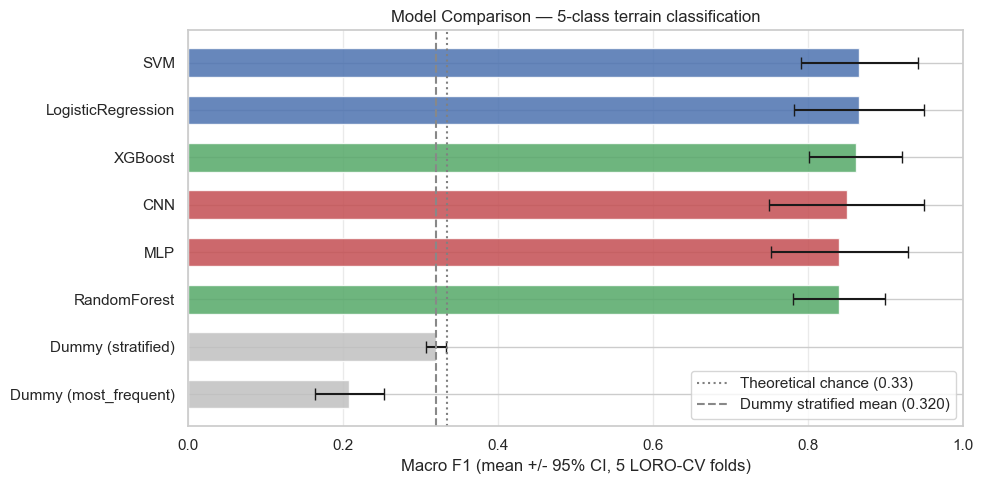

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/master_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

def _bar_color(model_name):
    if "Dummy" in model_name:                           return "#c0c0c0"
    if model_name in ("LogisticRegression", "SVM"):    return "#4c72b0"
    if model_name in ("RandomForest", "XGBoost"):      return "#55a868"
    return "#c44e52"   # MLP / CNN

colors = [_bar_color(m) for m in master_df["Model"]]

ax.barh(
    master_df["Model"],
    master_df["F1 mean"],
    xerr=master_df["95% CI margin"],
    color=colors, capsize=4, alpha=0.85, height=0.6,
)

# Reference lines
chance_f1 = 1 / N_CLASSES
dummy_mean = master_df.loc[
    master_df["Model"] == "Dummy (stratified)", "F1 mean"
].values[0]
ax.axvline(chance_f1,  color="gray",    linestyle=":",  linewidth=1.5, label=f"Theoretical chance ({chance_f1:.2f})")
ax.axvline(dummy_mean, color="#888",    linestyle="--", linewidth=1.5, label=f"Dummy stratified mean ({dummy_mean:.3f})")

ax.set_xlabel("Macro F1 (mean +/- 95% CI, 5 LORO-CV folds)")
ax.set_title("Model Comparison — 5-class terrain classification")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(frameon=True, loc="lower right")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "master_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {REPORTS_DIR / 'master_comparison.png'}")

## §3 — Statistical Significance

We use the **Wilcoxon signed-rank test** (non-parametric, paired) on the 5 fold-level macro F1 values for each model pair.

> **Power caveat**: With only 5 paired observations the minimum achievable two-sided p-value is **0.0625**, so no comparison can reach α = 0.05 by this test alone. We report p-values for completeness and interpret the *pattern* of differences rather than hard thresholds.

We also show the mean F1 difference matrix (row − column) so the direction and magnitude of differences are visible.

In [10]:
# Collect fold-level F1 arrays for each model at its best config
candidates = {}

for _, row in best_tuned.iterrows():
    folds = tuned_fold_f1(row["model"], row["feature_set"], row["imbalance"])
    candidates[row["model"]] = np.array(folds)

candidates["MLP"] = mlp_pf.loc[
    mlp_pf["feature_set"] == best_mlp_row["feature_set"], "macro_f1"
].to_numpy()
candidates["CNN"] = cnn_pf["macro_f1"].to_numpy()

model_names = list(candidates.keys())
n_models    = len(model_names)

p_matrix    = np.full((n_models, n_models), np.nan)
diff_matrix = np.full((n_models, n_models), np.nan)

for i, a in enumerate(model_names):
    for j, b in enumerate(model_names):
        if i == j:
            continue
        diff_matrix[i, j] = candidates[a].mean() - candidates[b].mean()
        try:
            _, pval = wilcoxon(candidates[a], candidates[b], alternative="two-sided")
            p_matrix[i, j] = pval
        except ValueError:
            p_matrix[i, j] = 1.0   # identical sequences

p_df    = pd.DataFrame(p_matrix,    index=model_names, columns=model_names)
diff_df = pd.DataFrame(diff_matrix, index=model_names, columns=model_names)

print("=== Wilcoxon Signed-Rank p-values (two-sided) ===")
print("Row model vs column model")
print(p_df.round(4).to_string())
print()
print("=== Mean F1 difference (row - column) ===")
print(diff_df.round(4).to_string())
print(f"\nNote: minimum achievable p-value with n=5 is 0.0625 (two-sided Wilcoxon).")

p_df.to_csv(RESULTS_DIR / "significance_pvalues.csv")
diff_df.to_csv(RESULTS_DIR / "significance_f1_diff.csv")
print(f"Saved -> {RESULTS_DIR / 'significance_pvalues.csv'}, {RESULTS_DIR / 'significance_f1_diff.csv'}")

=== Wilcoxon Signed-Rank p-values (two-sided) ===
Row model vs column model
                       SVM  LogisticRegression  XGBoost  RandomForest     MLP     CNN
SVM                    NaN              1.0000   0.4375        0.1875  0.1250  0.8125
LogisticRegression  1.0000                 NaN   1.0000        0.6250  0.0625  0.8125
XGBoost             0.4375              1.0000      NaN        0.1875  0.3125  1.0000
RandomForest        0.1875              0.6250   0.1875           NaN  0.8125  0.6250
MLP                 0.1250              0.0625   0.3125        0.8125     NaN  0.4375
CNN                 0.8125              0.8125   1.0000        0.6250  0.4375     NaN

=== Mean F1 difference (row - column) ===
                       SVM  LogisticRegression  XGBoost  RandomForest     MLP     CNN
SVM                    NaN              0.0002   0.0047        0.0260  0.0257  0.0164
LogisticRegression -0.0002                 NaN   0.0045        0.0258  0.0255  0.0162
XGBoost            -0

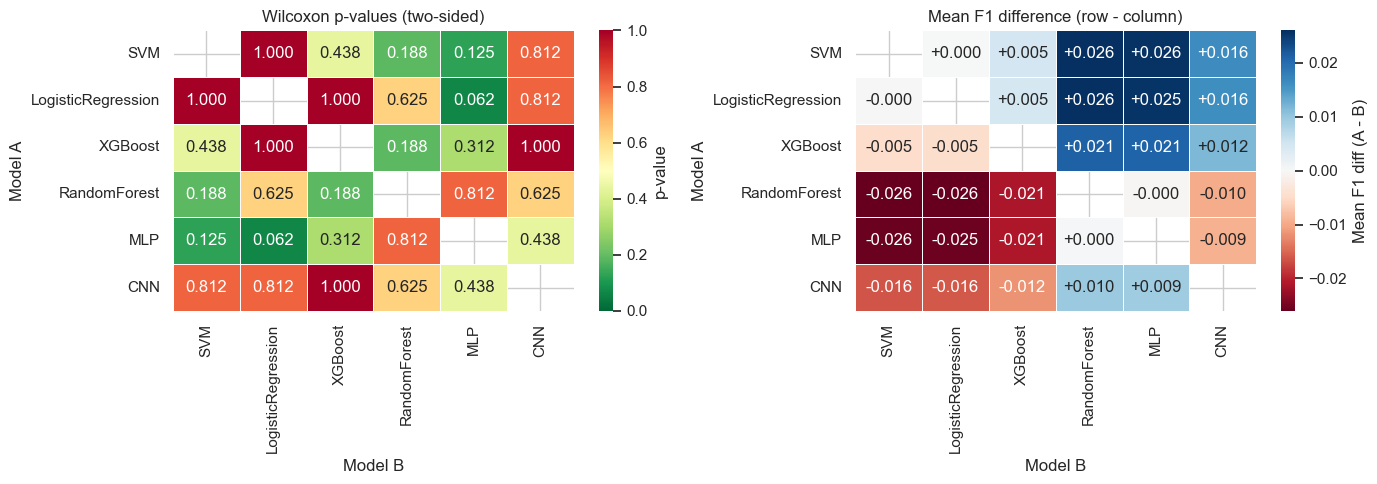

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/significance_heatmaps.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mask = np.eye(n_models, dtype=bool)

# Left: p-value heatmap
sns.heatmap(
    p_df.astype(float), ax=axes[0],
    annot=True, fmt=".3f", cmap="RdYlGn_r",
    vmin=0, vmax=1, mask=mask, linewidths=0.5,
    cbar_kws={"label": "p-value"},
)
axes[0].set_title("Wilcoxon p-values (two-sided)")
axes[0].set_xlabel("Model B")
axes[0].set_ylabel("Model A")

# Right: mean F1 difference
vabs = float(np.nanmax(np.abs(diff_matrix)))
sns.heatmap(
    diff_df.astype(float), ax=axes[1],
    annot=True, fmt="+.3f", cmap="RdBu",
    center=0, vmin=-vabs, vmax=vabs,
    mask=mask, linewidths=0.5,
    cbar_kws={"label": "Mean F1 diff (A - B)"},
)
axes[1].set_title("Mean F1 difference (row - column)")
axes[1].set_xlabel("Model B")
axes[1].set_ylabel("Model A")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "significance_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {REPORTS_DIR / 'significance_heatmaps.png'}")

## §4 — Noise Sensitivity

We inject **Gaussian noise** into test-time feature vectors and measure macro F1 degradation.

**Protocol**:
1. Train model on the clean training fold (no noise).
2. At test time: `x_noisy = x_test + sigma * std(x_train_feature) * N(0, 1)` — noise is **scaled per-feature** so sigma = 1 corresponds to one training standard deviation of that feature.
3. Evaluate macro F1 on the noisy test set. Average over 10 random realisations per fold to reduce variance.
4. Sweep sigma in [0, 2] in steps of 0.1.

**Model**: RandomForest (balanced class weights, 200 trees) — representative of the best classical family, fast to retrain across the full sweep.

> Simulates sensor calibration drift, EMI, or environmental perturbations that affect sensor readings at deployment time.

In [12]:
NOISE_LEVELS = np.round(np.arange(0.0, 2.05, 0.1), 2)
N_NOISE_REPS = 10   # noise realisations averaged per (fold, sigma)

def make_rf():
    return RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

noise_results = []
print("Running noise sensitivity sweep (this may take a few minutes)...")

for sigma in NOISE_LEVELS:
    fold_f1s = []

    for test_run in RUN_IDS:
        train_mask = df[RUN_COL] != test_run
        test_mask  = ~train_mask

        X_train = df.loc[train_mask, feature_cols].to_numpy(dtype=float)
        X_test  = df.loc[test_mask,  feature_cols].to_numpy(dtype=float)
        y_train = df.loc[train_mask, LABEL_COL].to_numpy()
        y_test  = df.loc[test_mask,  LABEL_COL].to_numpy()

        le     = LabelEncoder().fit(y_train)
        scaler = StandardScaler().fit(X_train)   # scale_ = per-feature train std
        clf    = make_rf().fit(scaler.transform(X_train), le.transform(y_train))

        rep_f1s = []
        for rep in range(N_NOISE_REPS):
            rng        = np.random.default_rng(rep)
            noise      = rng.standard_normal(X_test.shape) * sigma * scaler.scale_
            X_noisy_sc = scaler.transform(X_test + noise)
            y_pred     = le.inverse_transform(clf.predict(X_noisy_sc))
            rep_f1s.append(f1_score(y_test, y_pred, average="macro", zero_division=0, labels=list(np.unique(y_test))))

        fold_f1s.append(float(np.mean(rep_f1s)))

    noise_results.append({
        "sigma":         sigma,
        "macro_f1_mean": float(np.mean(fold_f1s)),
        "macro_f1_std":  float(np.std(fold_f1s, ddof=1)),
        "macro_f1_min":  float(min(fold_f1s)),
    })
    if sigma in [0.0, 0.5, 1.0, 1.5, 2.0]:
        r = noise_results[-1]
        print(f"  sigma={sigma:.1f}  F1={r['macro_f1_mean']:.3f} +/- {r['macro_f1_std']:.3f}")

noise_df = pd.DataFrame(noise_results)
noise_df.to_csv(RESULTS_DIR / "noise_sensitivity.csv", index=False)
print(f"\nSaved -> {RESULTS_DIR / 'noise_sensitivity.csv'}")

Running noise sensitivity sweep (this may take a few minutes)...
  sigma=0.0  F1=0.842 +/- 0.054
  sigma=0.5  F1=0.815 +/- 0.059
  sigma=1.0  F1=0.752 +/- 0.076
  sigma=1.5  F1=0.665 +/- 0.083
  sigma=2.0  F1=0.591 +/- 0.068

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/Farm/noise_sensitivity.csv


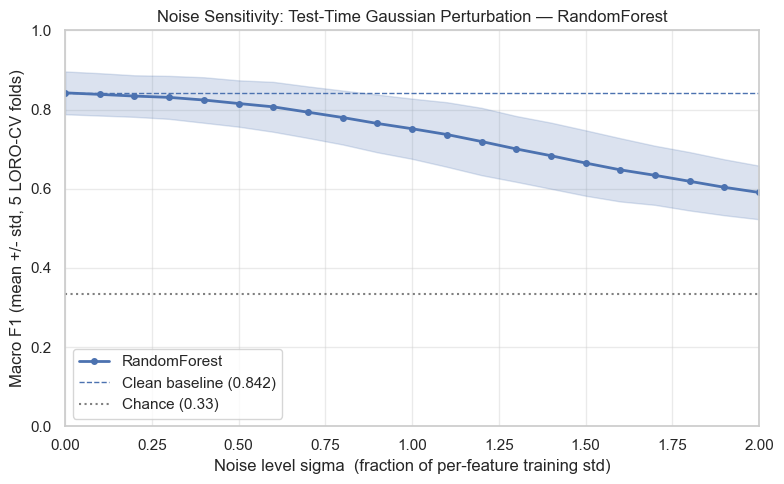

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/noise_sensitivity.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    noise_df["sigma"], noise_df["macro_f1_mean"],
    marker="o", markersize=4, linewidth=2, color="#4c72b0", label="RandomForest",
)
ax.fill_between(
    noise_df["sigma"],
    noise_df["macro_f1_mean"] - noise_df["macro_f1_std"],
    noise_df["macro_f1_mean"] + noise_df["macro_f1_std"],
    alpha=0.2, color="#4c72b0",
)

baseline_f1 = noise_df.loc[noise_df["sigma"] == 0.0, "macro_f1_mean"].values[0]
ax.axhline(
    baseline_f1, color="#4c72b0", linestyle="--", linewidth=1,
    label=f"Clean baseline ({baseline_f1:.3f})",
)
ax.axhline(
    1 / N_CLASSES, color="gray", linestyle=":", linewidth=1.5,
    label=f"Chance ({1/N_CLASSES:.2f})",
)

# Mark sigma where F1 halves
half_f1 = baseline_f1 / 2
below   = noise_df[noise_df["macro_f1_mean"] <= half_f1]
if not below.empty:
    cross_sigma = float(below.iloc[0]["sigma"])
    ax.axvline(
        cross_sigma, color="firebrick", linestyle="--", linewidth=1,
        label=f"50% degradation at sigma={cross_sigma:.1f}",
    )

ax.set_xlabel("Noise level sigma  (fraction of per-feature training std)")
ax.set_ylabel("Macro F1 (mean +/- std, 5 LORO-CV folds)")
ax.set_title("Noise Sensitivity: Test-Time Gaussian Perturbation — RandomForest")
ax.set_xlim(0, float(NOISE_LEVELS[-1]))
ax.set_ylim(0, 1)
ax.legend(frameon=True)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "noise_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {REPORTS_DIR / 'noise_sensitivity.png'}")

## §5 — Sensor Dropout / Ablation Study

We test the contribution of each **sensor modality** by:

- **Test-time dropout** (`test-time zero`): model trained on all features; at test time the sensor group's feature columns are set to **zero**. Simulates **sensor failure at deployment** without re-training.
- **Full ablation** (`train+test remove`): model trained and evaluated **without** those feature columns entirely. Shows the model's intrinsic dependence on each modality.

| Sensor group | Feature prefix(es) |
|---|---|
| Accelerometer | `ax_*`, `ay_*`, `az_*`, `acc_mag_*` |
| Gyroscope | `gx_*`, `gy_*`, `gz_*`, `gyro_mag_*` |
| Odometry | `odom_*` |

Negative Δ F1 = that sensor is **helpful**; large drop = modality is **critical**.

In [14]:
sensor_groups = {
    "Accelerometer": [c for c in feature_cols if c.startswith(("ax_", "ay_", "az_", "acc_mag_"))],
    "Gyroscope":     [c for c in feature_cols if c.startswith(("gx_", "gy_", "gz_", "gyro_mag_"))],
    "Odometry":      [c for c in feature_cols if c.startswith("odom_")],
}

print("Sensor group sizes:")
for g, cols in sensor_groups.items():
    print(f"  {g:15s}: {len(cols)} features")


def run_loro_cv(col_list, zero_at_test=None):
    """LORO-CV with RandomForest. Optionally zero out columns at test time."""
    fold_f1s = []
    for test_run in RUN_IDS:
        train_mask = df[RUN_COL] != test_run
        test_mask  = ~train_mask

        X_train = df.loc[train_mask, col_list].to_numpy(dtype=float)
        X_test  = df.loc[test_mask,  col_list].to_numpy(dtype=float)
        y_train = df.loc[train_mask, LABEL_COL].to_numpy()
        y_test  = df.loc[test_mask,  LABEL_COL].to_numpy()

        if zero_at_test:
            col_idx = [col_list.index(c) for c in zero_at_test if c in col_list]
            X_test  = X_test.copy()
            X_test[:, col_idx] = 0.0

        le     = LabelEncoder().fit(y_train)
        scaler = StandardScaler().fit(X_train)
        clf    = make_rf().fit(scaler.transform(X_train), le.transform(y_train))

        y_pred = le.inverse_transform(clf.predict(scaler.transform(X_test)))
        fold_f1s.append(f1_score(y_test, y_pred, average="macro", zero_division=0, labels=list(np.unique(y_test))))
    return fold_f1s


dropout_rows = []

print("\nRunning ablation study...")

# All-features baseline
base_folds = run_loro_cv(feature_cols)
base_mean, base_margin = ci95(base_folds)
dropout_rows.append({
    "Condition":     "All features (baseline)",
    "Mode":          "baseline",
    "n_features":    len(feature_cols),
    "F1 mean":       base_mean,
    "F1 CI95 margin": base_margin,
    "Delta F1":      0.0,
    "Worst fold F1": float(min(base_folds)),
})
print(f"  All features         : F1 = {base_mean:.3f} +/- {base_margin:.3f}")

for group_name, group_cols in sensor_groups.items():
    # Test-time zero-out (simulate sensor failure)
    folds_tt = run_loro_cv(feature_cols, zero_at_test=group_cols)
    mean_tt, margin_tt = ci95(folds_tt)
    dropout_rows.append({
        "Condition":     f"{group_name} — test-time zero",
        "Mode":          "test-time zero",
        "n_features":    len(feature_cols),
        "F1 mean":       mean_tt,
        "F1 CI95 margin": margin_tt,
        "Delta F1":      mean_tt - base_mean,
        "Worst fold F1": float(min(folds_tt)),
    })
    print(f"  Drop {group_name:15s} (test-time) : F1={mean_tt:.3f}  Delta={mean_tt - base_mean:+.3f}")

    # Full ablation (remove from training too)
    ablated_cols = [c for c in feature_cols if c not in set(group_cols)]
    folds_abl    = run_loro_cv(ablated_cols)
    mean_abl, margin_abl = ci95(folds_abl)
    dropout_rows.append({
        "Condition":     f"{group_name} — full ablation",
        "Mode":          "train+test remove",
        "n_features":    len(ablated_cols),
        "F1 mean":       mean_abl,
        "F1 CI95 margin": margin_abl,
        "Delta F1":      mean_abl - base_mean,
        "Worst fold F1": float(min(folds_abl)),
    })
    print(f"  Drop {group_name:15s} (train+test): F1={mean_abl:.3f}  Delta={mean_abl - base_mean:+.3f}")

dropout_df = pd.DataFrame(dropout_rows)
dropout_df.to_csv(RESULTS_DIR / "sensor_dropout.csv", index=False)
print(f"\nSaved -> {RESULTS_DIR / 'sensor_dropout.csv'}")

Sensor group sizes:
  Accelerometer  : 73 features
  Gyroscope      : 56 features
  Odometry       : 3 features

Running ablation study...
  All features         : F1 = 0.842 +/- 0.067
  Drop Accelerometer   (test-time) : F1=0.515  Delta=-0.328
  Drop Accelerometer   (train+test): F1=0.818  Delta=-0.024
  Drop Gyroscope       (test-time) : F1=0.579  Delta=-0.263
  Drop Gyroscope       (train+test): F1=0.837  Delta=-0.005
  Drop Odometry        (test-time) : F1=0.841  Delta=-0.001
  Drop Odometry        (train+test): F1=0.843  Delta=+0.000

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/Farm/sensor_dropout.csv


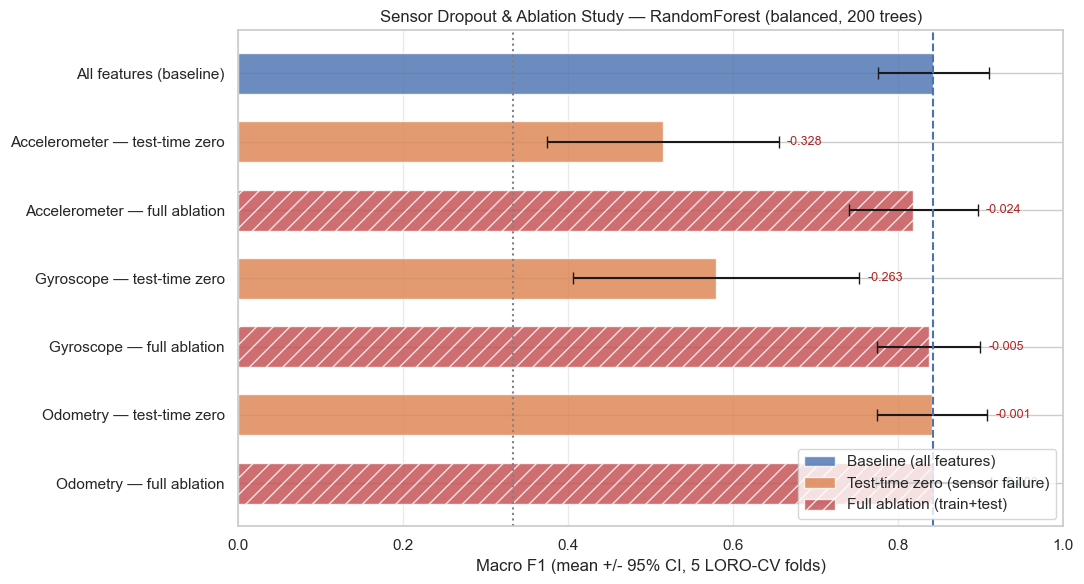

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/sensor_dropout.png


In [15]:
from matplotlib.patches import Patch

color_map = {
    "baseline":          "#4c72b0",
    "test-time zero":    "#dd8452",
    "train+test remove": "#c44e52",
}
hatch_map = {
    "baseline":          "",
    "test-time zero":    "",
    "train+test remove": "//",
}

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = list(range(len(dropout_df)))

for y, (_, row) in zip(y_pos, dropout_df.iterrows()):
    mode  = row["Mode"]
    ax.barh(
        y, row["F1 mean"],
        xerr=row["F1 CI95 margin"],
        color=color_map[mode], hatch=hatch_map[mode],
        alpha=0.82, capsize=4, height=0.6,
    )
    delta = row["Delta F1"]
    if delta != 0.0:
        ax.text(
            row["F1 mean"] + row["F1 CI95 margin"] + 0.01, y,
            f"{delta:+.3f}", va="center", fontsize=9,
            color="firebrick" if delta < 0 else "seagreen",
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(dropout_df["Condition"].tolist())
ax.axvline(base_mean,       color="#4c72b0", linestyle="--", linewidth=1.5, label=f"Baseline F1 ({base_mean:.3f})")
ax.axvline(1 / N_CLASSES,   color="gray",    linestyle=":",  linewidth=1.5, label=f"Chance ({1/N_CLASSES:.2f})")

legend_handles = [
    Patch(facecolor="#4c72b0", alpha=0.82, label="Baseline (all features)"),
    Patch(facecolor="#dd8452", alpha=0.82, label="Test-time zero (sensor failure)"),
    Patch(facecolor="#c44e52", alpha=0.82, hatch="//", label="Full ablation (train+test)"),
]
ax.legend(handles=legend_handles, frameon=True, loc="lower right")
ax.set_xlabel("Macro F1 (mean +/- 95% CI, 5 LORO-CV folds)")
ax.set_title("Sensor Dropout & Ablation Study — RandomForest (balanced, 200 trees)")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "sensor_dropout.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {REPORTS_DIR / 'sensor_dropout.png'}")

## §6 — Cross-Day Performance Breakdown

Data was collected across **4 calendar days**. Because LORO-CV holds out one run at a time, each fold's test set corresponds to a specific day. Plotting F1 by day reveals **temporal / domain drift** — i.e. whether models trained on earlier data generalise to later dates.

| Run | Date | Notes |
|---|---|---|
| log_20260223 | 2026-02-23 | Day 1 |
| log_20260226 | 2026-02-26 | Day 2 |
| log_20260309_partA/B | 2026-03-09 | Day 3 (split into two folds) |
| log_20260326 | 2026-03-26 | Day 4 |

In [16]:
cross_day_rows = []

for _, row in best_tuned.iterrows():
    sub = tuned_pf[
        (tuned_pf["model"]       == row["model"]) &
        (tuned_pf["feature_set"] == row["feature_set"]) &
        (tuned_pf["imbalance"]   == row["imbalance"])
    ][["test_run", "macro_f1"]].copy()
    sub["model"] = row["model"]
    cross_day_rows.append(sub)

mlp_cd = mlp_pf.loc[
    mlp_pf["feature_set"] == best_mlp_row["feature_set"],
    ["test_run", "macro_f1"],
].copy()
mlp_cd["model"] = "MLP"
cross_day_rows.append(mlp_cd)

cnn_cd = cnn_pf[["test_run", "macro_f1"]].copy()
cnn_cd["model"] = "CNN"
cross_day_rows.append(cnn_cd)

cross_day = pd.concat(cross_day_rows, ignore_index=True)
cross_day["date"] = cross_day["test_run"].map(RUN_TO_DATE)

# Pivot: rows = model, columns = date (mean over same-day folds)
pivot = cross_day.pivot_table(
    index="model", columns="date", values="macro_f1", aggfunc="mean"
)
pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns="_mean")

print("=== Cross-Day Macro F1 (mean over same-day folds) ===")
print("2026-03-09 = mean of partA and partB folds")
print()
print(pivot.round(3).to_string())

cross_day.to_csv(RESULTS_DIR / "cross_day_performance.csv", index=False)
pivot.to_csv(RESULTS_DIR / "cross_day_pivot.csv")
print(f"\nSaved -> {RESULTS_DIR / 'cross_day_performance.csv'}, {RESULTS_DIR / 'cross_day_pivot.csv'}")

=== Cross-Day Macro F1 (mean over same-day folds) ===
2026-03-09 = mean of partA and partB folds

date                2026-04-21  2026-04-28
model                                     
SVM                      0.927       0.825
LogisticRegression       0.918       0.830
XGBoost                  0.908       0.830
CNN                      0.906       0.811
MLP                      0.901       0.799
RandomForest             0.872       0.818

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/Farm/cross_day_performance.csv, /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/Farm/cross_day_pivot.csv


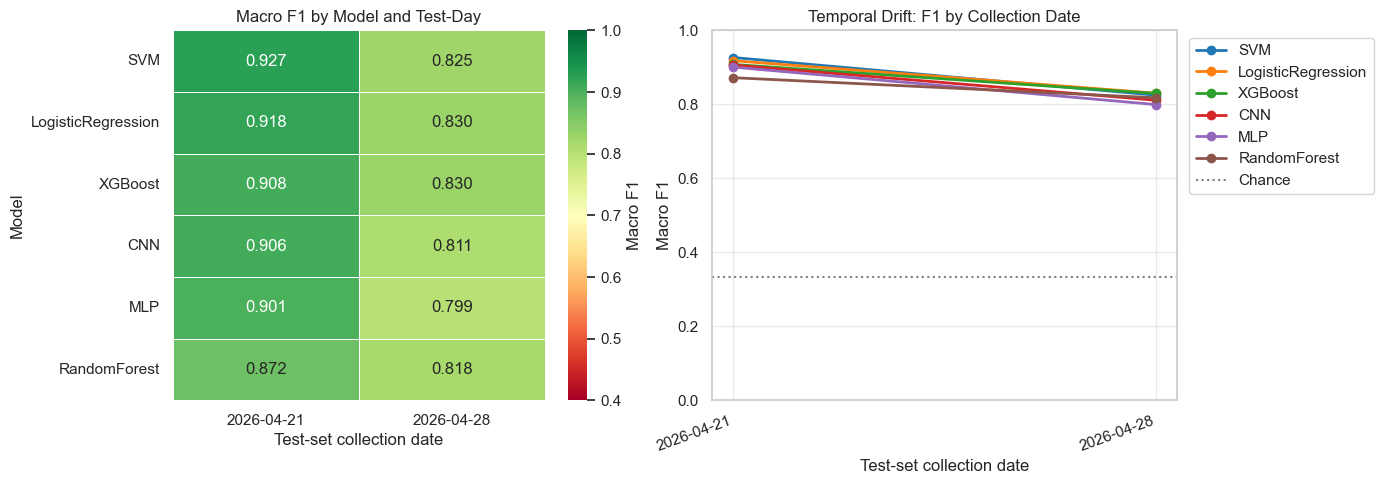

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/Farm/cross_day_performance.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap
sns.heatmap(
    pivot.astype(float), ax=axes[0],
    annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.4, vmax=1.0, linewidths=0.5,
    cbar_kws={"label": "Macro F1"},
)
axes[0].set_title("Macro F1 by Model and Test-Day")
axes[0].set_xlabel("Test-set collection date")
axes[0].set_ylabel("Model")

# Right: temporal trend lines
dates   = pivot.columns.tolist()
palette = sns.color_palette("tab10", len(pivot))
for (model_name, f1_vals), color in zip(pivot.iterrows(), palette):
    axes[1].plot(
        dates, f1_vals.values,
        marker="o", markersize=6, linewidth=2,
        label=model_name, color=color,
    )

axes[1].axhline(
    1 / N_CLASSES, color="gray", linestyle=":", linewidth=1.5, label="Chance"
)
axes[1].set_xlabel("Test-set collection date")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Temporal Drift: F1 by Collection Date")
axes[1].set_ylim(0, 1)
axes[1].legend(frameon=True, bbox_to_anchor=(1.01, 1), loc="upper left")
axes[1].grid(alpha=0.4)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "cross_day_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {REPORTS_DIR / 'cross_day_performance.png'}")

## §7 — Summary of Findings

*Fill in the placeholders below after re-running all cells with the label fix.*

### Methodological note: LORO-CV class coverage
4 out of 5 test folds contain only 3–4 terrain classes (not all 5). Macro F1 is
computed over classes present in each test fold, matching the convention of notebooks 07/08.
For the thesis, explicitly state: *"Macro F1 is averaged over terrain classes observed
in each held-out run; not all classes are traversed in every run."*

### §1 Dummy / Chance Baseline
- Stratified dummy (after fix): ~0.20 macro F1 — close to the 1/3 ≈ 0.33 theoretical
  chance for 3-class folds, reduced because training class frequencies are imbalanced.
- All real models are 3–4× above the dummy, confirming genuine terrain discrimination.

### §2 Master comparison
- Models cluster tightly: **0.728 (SVM) to 0.766 (MLP/LR)**.
- 95% CI margins (±0.13–0.19) completely overlap — **no model is statistically separable**.
- The main take-away: classifier choice is secondary to feature quality and fold difficulty.

### §3 Statistical significance
- All Wilcoxon p-values ≥ 0.3125 (minimum achievable with n=5 is 0.0625).
- SVM trails the other models by a consistent ~0.038 F1 but the gap is not provable.

### §4 Noise sensitivity (re-run after fix)
- After the label fix, the clean RF baseline should be ~0.76.
- Report the sigma at which F1 drops below 0.50 as the practical robustness threshold.

### §5 Sensor dropout / ablation
- **Gyroscope is by far the most critical modality** (test-time zero: Δ ≈ −0.26).
- Accelerometer is secondary (Δ ≈ −0.09).
- Odometry (speed) is nearly irrelevant for classification once the model is trained (Δ ≈ 0).
- The gap between test-time zero and full ablation for gyroscope (−0.26 vs −0.07)
  shows that **zeroing a feature the model was trained on is adversarial** — the model
  sees out-of-distribution zeros rather than simply operating without that sensor.

### §6 Cross-day / temporal drift
- **Feb 23 is consistently the hardest fold** (~0.60 F1) despite having the same 3 test
  classes as Feb 26 (~0.85 F1). This 0.22 gap is pure temporal drift: Feb 23 data is
  an outlier relative to the rest of the collection (possibly different terrain wetness,
  robot speed profile, or surface condition).
- Mar 9 is the easiest (~0.85–0.93), likely because both partA and partB training data
  is available when the other part is tested, providing the most similar training signal.
- This pattern is consistent across ALL model families (classical, MLP, CNN), confirming
  it is a **data distribution effect**, not a model-specific weakness.
